In [39]:
import scanpy as sc
import numpy as np
import anndata as ad
import seaborn as sns 
import matplotlib.pyplot as plt

In [8]:
adata_500k = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_celltype_pm_500k_filtered_.h5ad")
adata_total = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/new_dataset/BloodPlus_Logicle_pm_.h5ad")

In [10]:
is_annot = adata_total.obs.index.isin(adata_500k.obs.index)
adata_total.obs["is_annot"] = is_annot

In [11]:
adata_500k.obs["is_annot"] = True 

In [12]:
adata_total = adata_total[~adata_total.obs.is_annot]
sc.pp.subsample(adata_total, n_obs=500000)

In [13]:
adata_concat = ad.concat([adata_500k, adata_total]) 

In [16]:
adata_concat.obs.is_annot.value_counts()

is_annot
False    500000
True     471836
Name: count, dtype: int64

In [17]:
sc.pp.neighbors(adata_concat)
sc.tl.umap(adata_concat)

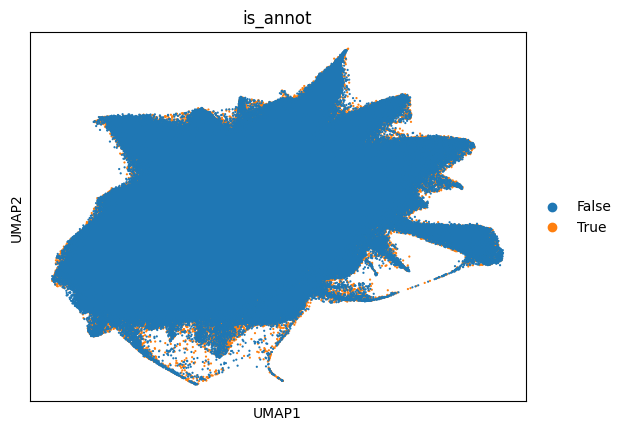

In [25]:
sc.pl.umap(adata_concat, color="is_annot", s=10, groups=[True])

## Additional analysis 

* Take unannotated data
* Per cell type
* Take neighborhood and compute frac unannotated vs. annotated
* if largely != 0.5 --> cell type has some uncovered region 

In [42]:
adata_100k_old_data = sc.read_h5ad("/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/data/gdrive/dataset_unmix8/ds_HID01_logicle_100k_UMAP_ann.h5ad")
adata_100k_old_data = adata_100k_old_data[:, adata_500k.var.index]

In [43]:
adata_100k_old_data.X.shape

(100000, 20)

In [44]:
adata_500k.X.shape

(471836, 20)

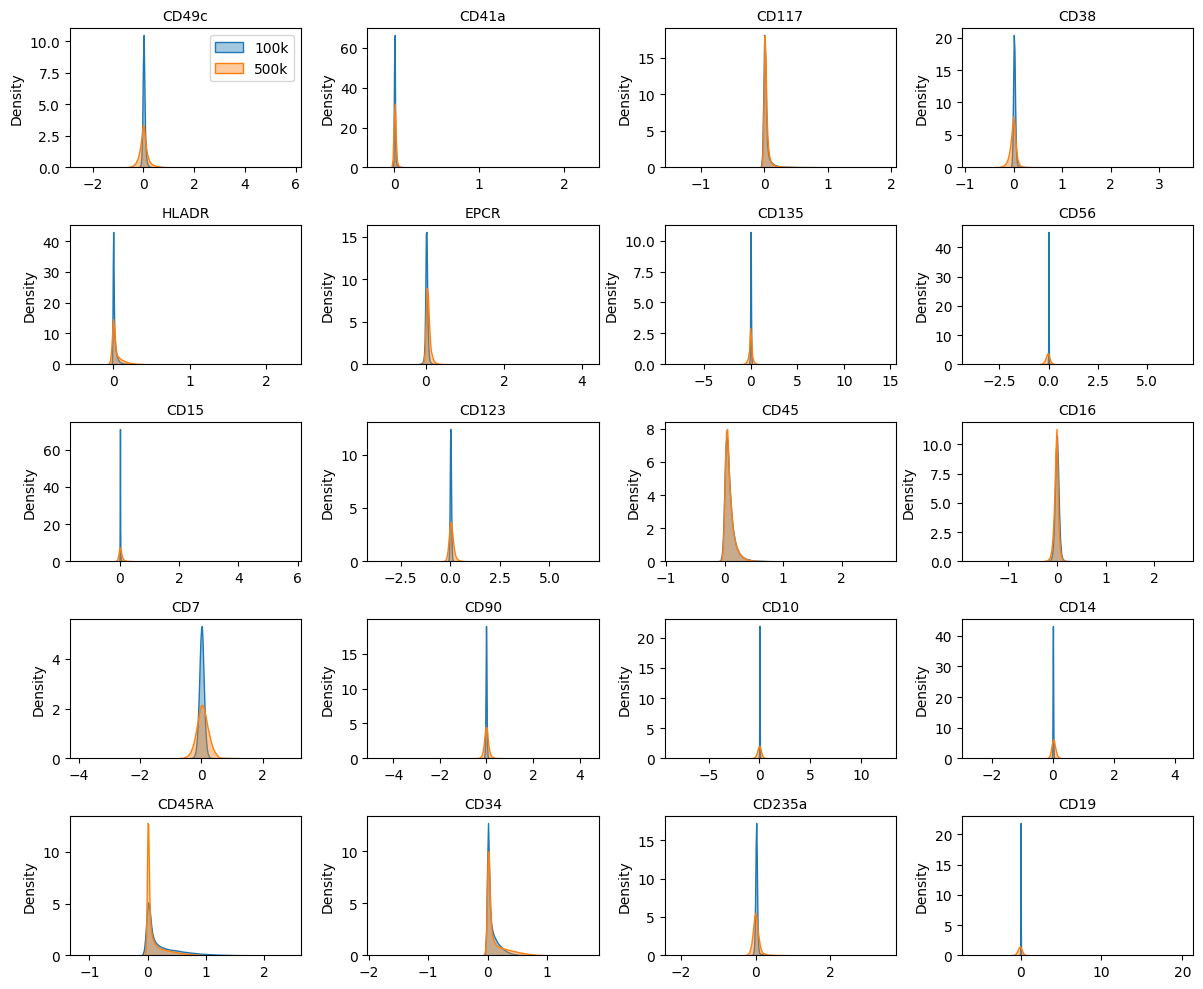

In [49]:
X1 = adata_100k_old_data.X
X2 = adata_500k.X

feature_names = adata_100k_old_data.var.index  # assume same features/order

# Convert sparse → dense if needed
if not isinstance(X1, np.ndarray):
    X1 = X1.toarray()
if not isinstance(X2, np.ndarray):
    X2 = X2.toarray()

n_features = X1.shape[1]

n_cols = 4
n_rows = int(np.ceil(n_features / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 2*n_rows))
axes = axes.flatten()

for i in range(n_features):
    ax = axes[i]
    
    sns.kdeplot(X1[:, i], ax=ax, fill=True, alpha=0.4, label="100k")
    sns.kdeplot(X2[:, i], ax=ax, fill=True, alpha=0.4, label="500k")
    
    ax.set_title(feature_names[i], fontsize=10)
    ax.set_ylabel("Density")
    ax.set_xlabel("")
    
    # Only show legend on first subplot to avoid clutter
    if i == 0:
        ax.legend()
    else:
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

# Remove empty subplots
for j in range(n_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()